# Machine Learning: Bai thuc hanh so 4
- Trong tuần này chúng ta sẽ thực hành phương pháp K-NN và phương pháp Hồi quy SoftMax giải quyết bài toán phần loại với đầu ra có C > 2 phân lớp. 
- Phần K-NN chúng ta sẽ cố gắng dùng lại các đoạn code đã có trong các bài thực hành trước. 
- Ngoài ra, trong ví dụ cuối cùng chúng ta sẽ thử thực hiện phân loại cho một dạng dữ liệu không có cấu trúc bảng như trước, đó là dạng ảnh chữ số viết tay.
Các bạn đọc kỹ hướng dẫn và thực hiện các yêu cầu trong bài thực hành.




## Off bai thuc hanh 
- cac loai phan lop (cac chien luoc phan lop):
+ One - vs - Reset
 Vd: co 3 nhan, phan loai 3 nhan. can chia thanh 3 mat phang, can 3 x (d + 1) tham so theta
+ one - vs - one 

 Khac biet ve so luong tham so, kieu phan loai
 Xay dung ham loss de keo mien gia tri ve (0,1) -> keo ve phan loai xac suat doi voi ham phan loai don
 Doi voi nhieu nhan thi lms de phan loai => ham softmax:

 - Cau hoi lien quan den softmax trong bai thi giua ky chi co the xem o tiet ly thuet(thay day)

+ So tham so trong bai hoi quy logistic de tim ra nhan (0, 1) can bao nhieu tham so: d + 1. Muc tieu tim ra mot cai sieu phang va dung ham loss be cong no



## A. Phuong Phap KNN cho Phan loai Nhieu Lop 
- (i) Với mỗi x – unseen ở đầu vào (các phần tử trong tập Validation)
- (ii) Tính khoảng cách di từ x đến các xi trong tập Training => Lập thành 1 mảng.
- (iii) Sắp xếp các khoảng cách này theo thứ tự tăng dần, nhưng cần có tham chiếu để biết chỉ số phần
tử ban đầu trong mảng di
- (iv) Tìm ra K chỉ số của các phần tử xi trong tập Training ứng với các di nhỏ nhất. Gọi tập này là nj ,
j =1, 2, … K.
- (v) Xác định nhãn L có tần suất xuất hiện nhiều nhất trong tập đầu ra của các mẫu huấn luyện ynj. Đầu
ra dự đoán y_pred := L.
- Ở đây chúng ta chỉ cần bổ sung phương thức tìm phần tử (nhãn) có tần suất xuất hiện nhiều nhất trong tập {ynj}. Phương thức này có thể xây dựng như sau:
### Chú ý:
- Trong phương thức này đầu vào arr phải là list
- Giá trị trả về là mẫu có tần suất xuất hiện cao nhất. Ví dụ đầu vào Arr = [1, 2, 4, 2, 5, 2, 7, 9] thì giá
trị trả về là 2

In [1]:
def highest_rank(arr):
    count_num = {}
    for i in arr:
        count_num[i] = arr.count(i)
    return max(count_num, key = count_num.get)

## Vi du A.1

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
N = 500 # random data
d = 2 # so chieu
C = 3 # so lop c =0,1,2

means = [[2,2], [8,3], [3,6]] # Tam cac diem cua 3 lop c1,c2,c3
cov = [[1,0], [0,1]] # ma tran hiep phuong sai chung cho toan bo tam 

# Gen data
x0 = np.random.multivariate_normal(means[0], cov, N)
x1 = np.random.multivariate_normal(means[1], cov, N)
x2 = np.random.multivariate_normal(means[2], cov, N)

x = np.concatenate((x0, x1, x2), axis = 0).T

# Gen label for data points of each class (0,1,2)
# Tao ra N so 0, N so 1, N so 2, chuyen list ve array 
original_label = np.asarray([0]*N + [1]*N + [2]*N).T

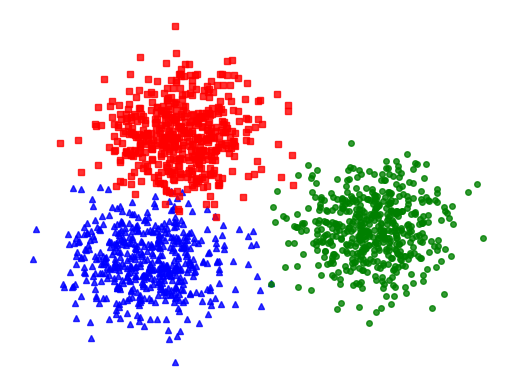

In [4]:
def display(x, label):
    x0 = x[:, label == 0]
    x1 = x[:, label == 1]
    x2 = x[:, label == 2]
    
    plt.plot(x0[0, :], x0[1, :], 'b^', markersize = 4, alpha = .8) # blue, tam giac
    plt.plot(x1[0, :], x1[1, :], 'go', markersize = 4, alpha = .8) # gree cricle
    plt.plot(x2[0, :], x2[1, :], 'rs', markersize = 4, alpha = .8) # red square
    plt.axis("off") # an truc x, y 
    plt.plot()
    plt.show()
    
display(x[0:, :], original_label)
    

In [5]:
x_train = np.concatenate((x0[:400], x1[:400], x2[:400]), axis = 0)
y_train = np.concatenate((original_label[:400], original_label[500:900]
                        , original_label[1000:1400]), axis = 0)
x_val = np.concatenate((x0[400:], x1[400:], x2[400:]), axis = 0)
y_val = np.concatenate((original_label[400:500], original_label[900:1000],
original_label[1400:1500]), axis = 0)

print(x_train.shape, y_train.shape, x_val.shape, y_val.shape)

(1200, 2) (1200,) (300, 2) (300,)


In [6]:
def distance(array, value):
    array = np.array(array)
    return np.linalg.norm(array - value, ord = 2, axis = 1) 
    # axis: so chieu bat dau tinh tu 0

def find_nearest_index(array, value, k):
    array_D = distance(array, value)
    return np.argsort(array_D)[:k]



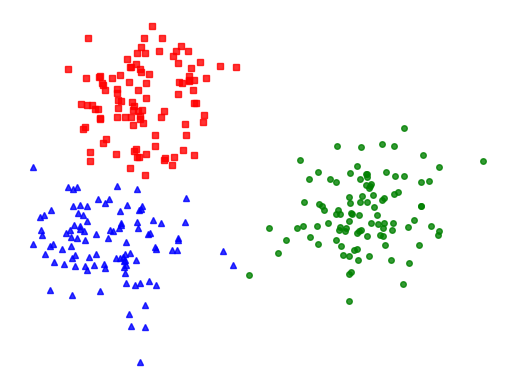

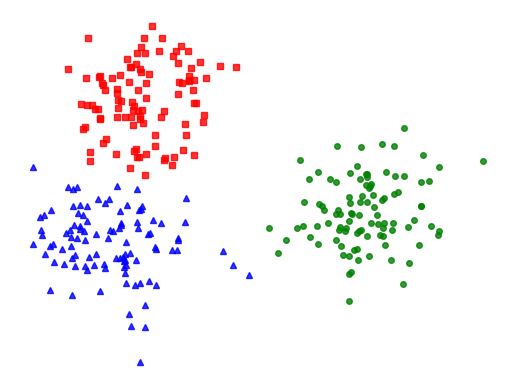

In [7]:
# Dat K = 20 va su dung pp KNN de du doan phan lop 
K = 20
y_pred = np.zeros(len(y_val)).astype(int) # tao mot array toan so 0
for j in range(len(y_val)):
    indexes = find_nearest_index(x_train, x_val[j], K)
    y_nearest = []
    for i in range(K):
        y_nearest.append(y_train[indexes[i]])
    
    y_pred[j] = highest_rank(y_nearest)
    


display(x_val.T, y_val)
display(x_val.T, y_pred)

## Vi du A.2
- Trong ví dụ này chúng ta sẽ sử dụng scikit-learn sklearn với bộ dữ liệu thực phân loại hoa IRIS
theo kích thước cánh và đài hoa (https://archive.ics.uci.edu/ml/datasets/iris) .
* Thông tin về dữ liệu phân loại hoa IRIS như sau:
- Số chiều d = 4 bao gồm các thuộc tính: sepal length, sepal width, petal length, petal width;
- Các trường đều là giá trị thực(tính theo cm);
- Có tổng cộng 150 điểm dữ liệu;
- Có 03 loại (lớp – classes): setosa, versicolor, virginica , mỗi phân lớp đều có 50 mẫu. \\
- Dữ liệu được phân bố đều cho mỗi loại (mỗi phân lớp có 50 mẫu dữ liệu). Đầu tiên chúng ta sẽ load dữ liệu
và thử vẽ ra các điểm dữ liệu để có hình dung trực quan về các phân lớp của dữ liệu.
- Do dữ liệu của ta có 04 chiều nên không thể vẽ nguyên bản lên mặt phẳng. Vì vậy trong đoạn code dưới đây
chúng ta sử dụng gói PCA (Principal Components Analysis) để phân tích và chiếu dữ liệu xuống không gian
hai (02) chiều thể hiện được gần đúng nhất cấu trúc dữ liệu (thành phần chủ yếu - Principal Components

In [8]:
import pandas as pd
from sklearn.decomposition import PCA as sklearnPCA
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

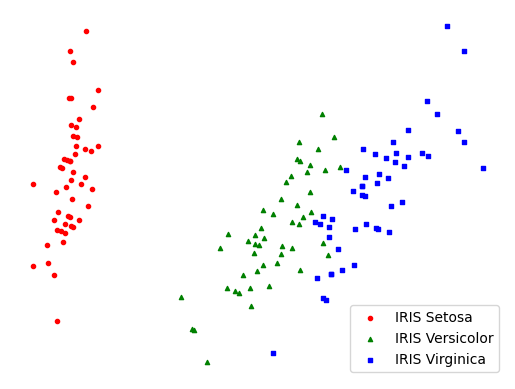

In [9]:
iris = datasets.load_iris()
x = iris.data[:, :4] 
Y = iris.target
x_norm = (x - x.min()) / (x.max() - x.min())
pca = sklearnPCA(n_components=2) #2-dimensional PCA
transformed = pd.DataFrame(pca.fit_transform(x_norm))
plt.axis("off")
plt.scatter(transformed[Y==0][0], transformed[Y==0][1], s=9, label='IRIS Setosa',
c='red')
plt.scatter(transformed[Y==1][0], transformed[Y==1][1], s=9, label='IRIS Versicolor',
c='green', marker="^")
plt.scatter(transformed[Y==2][0], transformed[Y==2][1], s=9, label='IRIS Virginica',
c='blue', marker="s")
plt.legend()
plt.show()

- Tiếp theo, hãy chia dữ liệu mỗi loại hoa thành 2 phần, 40 mẫu đầu đưa vào tập Train và 10 mẫu sau đưa vào
tập Validation. Có thể tham khảo đoạn code trong Ví dụ A.1., tuy nhiên cần chú ý chọn chiều (axis) phù hợp.
- Sử dụng chương trình cho phương pháp K-NN đã có và dựa vào tập Train, thực hiện dự đoán phân loại các
mẫu trong tập Validation. Sử dụng các độ đo như Accuracy, Precision, Confusion Matrix để đánh giá độ chính
xác của phương pháp.

In [10]:
# Lay data cu the cac loai hoa 
# cach 1: do du lieu da sap xep => lay truc tiep 
x0 = x[0:50]
x1 = x[50:100]
x2 = x[100:150]
y0 = Y[0:50]
y1 = Y[50:100]
y2 = Y[100:150]


In [11]:
#cach 2: minh dua vao bien y de tim
def display(x, y):
    x0 = x[y == 0]
    x1 = x[y == 1]
    x2 = x[y == 2]
    plt.plot(x0[:, 0], x0[:, 1], 'b^', markersize = 4, alpha = .8) # blue, tam giac
    plt.plot(x1[:, 0], x1[:, 1],  'go', markersize = 4, alpha = .8) # gree cricle
    plt.plot(x2[:, 0], x2[:, 1],  'rs', markersize = 4, alpha = .8) # red square
    plt.axis("off") # an truc x, y
    plt.plot()
    plt.show()

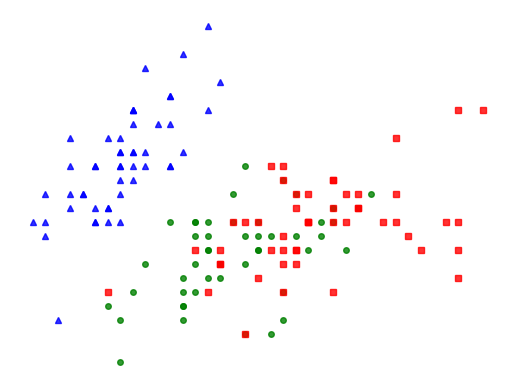

In [12]:
display(x, Y)

In [13]:
# Chia du lieu train tesst
x0_train = x0[:40]
x0_test = x0[40:]
x1_train = x1[:40]
x1_test = x1[40:]
x2_train = x2[:40]
x2_test = x2[40:]

# ket noi cac du lieu 
x_train = np.concatenate((x0_train, x1_train, x2_train), axis = 0)
x_test = np.concatenate((x0_test, x1_test, x2_test), axis= 0)

y_train = np.concatenate((y0[0:40], y1[0:40], y2[0:40]), axis = 0)
y_test = np.concatenate((y0[40:], y1[40:], y2[40:]))


- Numpy 

In [14]:
def distance(array, value):
    array = np.array(array)
    return np.linalg.norm(array - value, ord =2, axis = 1) #ord = 2: khoang cach Eculid


def highest_rank(arr):
    count_num = {}
    for i in arr:
        count_num[i] = arr.count(i)
    return max(count_num, key = count_num.get)

def find_nearest_index(array, value, k):
    array_D = distance(array, value)
    return np.argsort(array_D)[:k]

In [15]:
# dat K = 20 va su dung phuong phap KNN cho phan lop
def KNN(x_train, y_train, x_test, k):
    y_pred = np.zeros(len(x_test)).astype(int) 
    for i in range(len(x_test)):
        indexes = find_nearest_index(x_train, x_test[i], k)
        y_nearest = []
        for j in range(k):
            y_nearest.append(y_train[indexes[j]])
            
        y_pred[i] = highest_rank(y_nearest)
    
    return y_pred


In [16]:
# thuc hien du doan phan loai cac mau 
k = 4
y_prev = (KNN(x_train, y_train, x_test, k))

compairison = pd.DataFrame({'y_test' : y_test, 'y_prev' : y_prev})


In [17]:
print(compairison)

    y_test  y_prev
0        0       0
1        0       0
2        0       0
3        0       0
4        0       0
5        0       0
6        0       0
7        0       0
8        0       0
9        0       0
10       1       1
11       1       1
12       1       1
13       1       1
14       1       1
15       1       1
16       1       1
17       1       1
18       1       1
19       1       1
20       2       2
21       2       2
22       2       2
23       2       2
24       2       2
25       2       2
26       2       2
27       2       2
28       2       2
29       2       2


- Library

In [18]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
compairison = pd.DataFrame({'y_test' : y_test, 'y_prev' : y_pred})
print(compairison)

    y_test  y_prev
0        0       0
1        0       0
2        0       0
3        0       0
4        0       0
5        0       0
6        0       0
7        0       0
8        0       0
9        0       0
10       1       1
11       1       1
12       1       1
13       1       1
14       1       1
15       1       1
16       1       1
17       1       1
18       1       1
19       1       1
20       2       2
21       2       2
22       2       2
23       2       2
24       2       2
25       2       2
26       2       2
27       2       2
28       2       2
29       2       2


In [19]:
# Accuracy 
def accuracy(y_test, y_pred):
    count = 0
    for i in range(len(y_test)):
        if y_test[i] == y_pred[i]:
            count += 1
            
    return (count / len(y_test))
    
# Precision 
def precision(y_test, y_pred):
    classes = np.unique(y_test)
    pre = []
    for c in classes:
        tp = 0
        fp = 0
        
        for i in range(len(y_test)):
            if y_pred[i] == c:
                if y_test[i] == c:
                    tp += 1
                else:
                    fp += 1
        if tp + fp == 0:
            pre.append(0)
        else: 
            pre.append(tp / (tp + fp))
    
    return sum(pre) / len(pre)


# confusion matrix 
def confusion_matrix(y_test, y_pred):
    n = len(set(y_test))
    matrix = np.zeros((n, n), dtype=int)
    for i in range(len(y_test)):
        matrix[y_test[i],  y_pred[i]] += 1
    
    return matrix

print('accuracy:', accuracy(y_test, y_pred))
print('precision:', precision(y_test, y_pred))
print('confusion_matrix:', confusion_matrix(y_test, y_pred))

accuracy: 1.0
precision: 1.0
confusion_matrix: [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


In [20]:
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix
acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred, average='macro')
matrix = confusion_matrix(y_test, y_pred)
print('accuracy:', acc)
print('precision:', pre)
print('confusion_matrix:', matrix)

accuracy: 1.0
precision: 1.0
confusion_matrix: [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


- Nhan xet:
- Ket qua thuc nghiem cho thay mo hinh KNN phan loai dung tren tap validation voi accuracy va precision = 1, confussion matrix la ma tran duong cheo cho thay cac mau deu duoc phan loai chinh xac theo dung tung lop


## B. Hoi quy softmax(multinomial logistic regression)
### Vi du B.1

- Trong ví dụ này, chúng ta sẽ dùng toàn bộ tập điểm như là training data và áp dụng mô hình hồi quy Logistic
nhiều lớp để xác định đường phân chia các lớp của dữ liệu.
Sau đó các bạn có thể sinh ngẫu nhiên một số điểm dữ liệu và sử dụng các tham số tối ưu đã tìm được để dữ
đoán xem các điểm dữ liệu tương ứng thuộc lớp nào.
- Trong ví dụ này, chúng ta sẽ tự xây dựng các phương thức chính của mô hình hồi quy Logistic nhiều lớp,
chỉ dựa vào các công cụ cơ bản trong thư viện Numpy.

In [56]:
import numpy as np
import matplotlib.pyplot as plt

N = 500
d = 2
c = 3

means = [[2,2], [8,3], [3,6]]
cov = [[1, 0], [0, 1]]

X0 = np.random.multivariate_normal(means[0], cov, N)
X1 = np.random.multivariate_normal(means[1], cov, N)
X2 = np.random.multivariate_normal(means[2], cov, N)

X = np.concatenate((X0, X1, X2), axis = 0).T

X = np.concatenate((np.ones((1, 3*N)), X), axis = 0)
# Gen label for data points of each class (0,1,2)
# Tao ra N so 0, N so 1, N so 2, chuyen list ve array 
original_label = np.asarray([0]*N + [1]*N + [2]*N).T

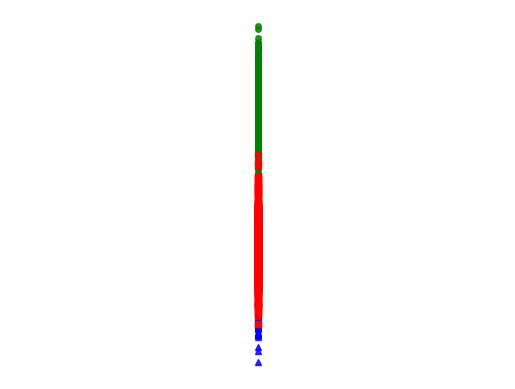

In [57]:
def display(x, label):
    x0 = x[:, label == 0]
    x1 = x[:, label == 1]
    x2 = x[:, label == 2]
    
    plt.plot(x0[0, :], x0[1, :], 'b^', markersize = 4, alpha = .8) # blue, tam giac
    plt.plot(x1[0, :], x1[1, :], 'go', markersize = 4, alpha = .8) # gree cricle
    plt.plot(x2[0, :], x2[1, :], 'rs', markersize = 4, alpha = .8) # red square
    plt.axis("off") # an truc x, y 
    plt.plot()
    plt.show()
    
display(X[0:, :], original_label)
    

- Xây dựng các phương thức cần cho mô hình hồi quy logistic nhiều lớp:
- Hàm chuyển từ một vector dữ liệu sang dạng one-hot-coding tức là các vector chỉ gồm 0/1/2 ứng với các
nhãn của điểm dữ liệu:

In [58]:
from scipy import sparse

def convert_labels(y, C = C):
    """
        convert 1d label to a matrix label: each column of this
        matrix coresponding to 1 element in y. In i-th column of Y,
        only one non-zeros element located in the y[i]-th position,
        and = 1 ex: y = [0, 2, 1, 0], and 3 classes then return
        [[1, 0, 0, 1],
        [0, 0, 1, 0],
        [0, 1, 0, 0]]
    """
    Y = sparse.coo_matrix((np.ones_like(y),(y, np.arange(len(y)))), shape = (C, len(y))).toarray()
    return Y
# Y = convert_labels(y, C)


In [59]:
def softmax_stable(Z):
    """
        Compute softmax values for each sets of scores in Z.
        each column of Z is a set of score.
    """
    e_Z = np.exp(Z - np.max(Z, axis = 0, keepdims = True))
    A = e_Z / e_Z.sum(axis = 0)
    return A

def softmax(Z):
    """
        #Compute softmax values for each sets of scores in V.
        #each column of V is a set of score.
    """
    e_Z = np.exp(Z)
    A = e_Z / e_Z.sum(axis = 0)
    return A

def softmax_regression(X, y, W_init, eta, tol = 1e-4, max_count = 10000):
    W = [W_init]
    C = W_init.shape[1]
    Y = convert_labels(y, C)
    it = 0
    N = X.shape[1]
    d = X.shape[0]
    count = 0
    check_w_after = 20
    while count < max_count:
    # mix data
        mix_id = np.random.permutation(N)
        for i in mix_id:
            xi = X[:, i].reshape(d, 1)
            yi = Y[:, i].reshape(C, 1)
            ai = softmax(np.dot(W[-1].T, xi))
            W_new = W[-1] + eta*xi.dot((yi - ai).T)
            count += 1
            # stopping criteria
            if count%check_w_after == 0:
                if np.linalg.norm(W_new - W[-check_w_after]) < tol:
                    return W
    
            W.append(W_new)
    return W

# cost or loss function
def cost(X, Y, W):
    A = softmax(W.T.dot(X))
    return -np.sum(Y*np.log(A))

# Predict that X belong to which class (1..C now indexed as 0..C-1 )
def pred(W, X):
    """
        predict output of each columns of X
        Class of each x_i is determined by location of max probability
        Note that class are indexed by [0, 1, 2, ...., C-1]
    """
    A = softmax_stable(W.T.dot(X))
    return np.argmax(A, axis = 0)
# W[-1] is the solution, W is all history of weights

In [60]:
eta = .05
d = X.shape[0]
W_init = np.random.randn(X.shape[0], C)
W = softmax_regression(X, original_label, W_init, eta)
print(W[-1])

[[ 9.17893963 -3.42377375 -2.76170012  1.24452778  0.36552399  1.77475757
  -1.16343    -0.27660162 -0.71431041 -0.36924342  2.23120053  0.62239121
   0.11292109 -1.03636802  1.72932429  1.39523917  0.83289525  0.71105406
   1.6368961  -0.39944593]
 [ 0.19681569  2.82237758  0.33946739 -1.67118434 -0.47782753 -0.66649312
  -0.15691974 -2.38656131  0.69612309 -0.08669826 -2.08509116  0.24215259
  -0.02045994  0.46092306 -0.575602   -0.32648852 -0.73187464  0.25688372
  -1.20671904 -1.0057368 ]
 [ 0.20042868  0.4620039   3.33045529  0.27947833 -1.04177072 -0.05542781
   0.68638869  0.24859703 -1.09824424 -0.09198018  0.04254448 -0.73476245
  -0.06054305 -0.99806789 -0.4159629  -0.88269789 -0.66735852 -0.8153343
  -2.18827987 -1.71162572]]


(1, 270400)
(3, 270400)


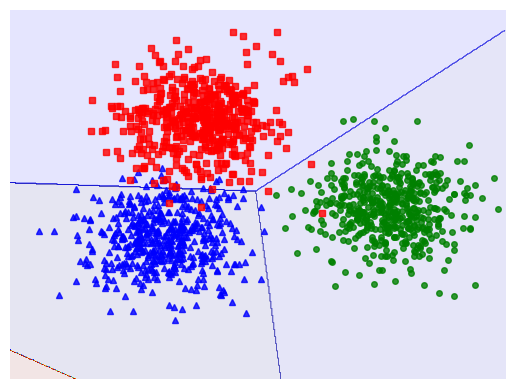

<Figure size 640x480 with 0 Axes>

In [61]:
#Visualize
xm = np.arange(-2, 11, 0.025)
xlen = len(xm)
ym = np.arange(-3, 10, 0.025)
ylen = len(ym)
xx, yy = np.meshgrid(xm, ym)
print(np.ones((1, xx.size)).shape)
xx1 = xx.ravel().reshape(1, xx.size)
yy1 = yy.ravel().reshape(1, yy.size)
XX = np.concatenate((np.ones((1, xx.size)), xx1, yy1), axis = 0)
print(XX.shape)
Z = pred(W[-1], XX)
Z = Z.reshape(xx.shape)
CS = plt.contourf(xx, yy, Z, 200, cmap='jet', alpha = .1)
plt.xlim(-2, 11)
plt.ylim(-3, 10)
plt.xticks(())
plt.yticks(())
display(X[1:, :], original_label)
plt.savefig('ex1.png', bbox_inches='tight', dpi = 300)
plt.show()

### Vi du B.2

- Trong ví dụ này chúng ta sẽ sử dụng scikit-learn sklearn với bộ dữ liệu thực phân loại hoa IRIS
theo kích thước cánh và đài hoa



In [27]:
import pandas as pd
from sklearn.decomposition import PCA as sklearnPCA
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
import seaborn as sns 

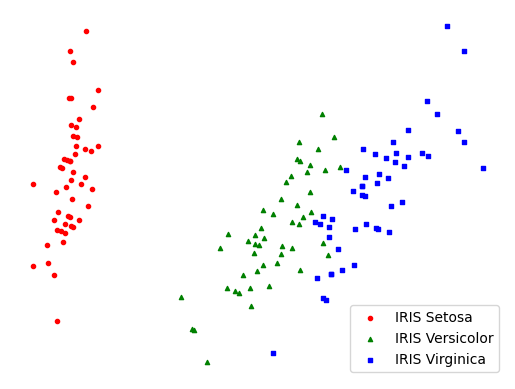

In [28]:
iris = datasets.load_iris()
x = iris.data[:, :4] 
Y = iris.target
x_norm = (x - x.min()) / (x.max() - x.min())
pca = sklearnPCA(n_components=2) #2-dimensional PCA
transformed = pd.DataFrame(pca.fit_transform(x_norm))
plt.axis("off")
plt.scatter(transformed[Y==0][0], transformed[Y==0][1], s=9, label='IRIS Setosa',
c='red')
plt.scatter(transformed[Y==1][0], transformed[Y==1][1], s=9, label='IRIS Versicolor',
c='green', marker="^")
plt.scatter(transformed[Y==2][0], transformed[Y==2][1], s=9, label='IRIS Virginica',
c='blue', marker="s")
plt.legend()
plt.show()

- a) Bài tập tự thực hành 1: Áp dụng chương trình tự xây dựng các hàm/phương thức từ numpy:
- Các bạn hãy sử dụng những công cụ đã có ở Ví dụ B.1, sau đó tham khảo lại cấu trúc dữ liệu cvs về hoa
IRIS đã có ở phần nhóm các phương pháp Naïve Bayes (Gaussian Naïve Bayes), tìm các đọc dữ liệu và
có các thao tác phù hợp để sử dụng các hàm/phương thức đã xây dựng trong Ví dụ 1, thực hiện quá trình
training và prediction với dữ liệu được chia theo tỉ lệ: train:validation = 4:1 (phân chia đều theo mỗi loại
hoa – tự các bạn viết đoạn code để phân chia). Các bạn hoàn thành phần này như là bài tập.

In [29]:
iris = pd.read_csv("iris.csv")

iris = iris.rename(columns = {'sepal.length': '1_sepal_length',
                                           'sepal.width': '2_sepal_width',
                                           'petal.length': '3_petal_length',
                                           'petal.width': '4_petal_width'})
iris.head(5)


,1_sepal_length,2_sepal_width,3_petal_length,4_petal_width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


Text(0.5, 1.0, 'Scatter plot')

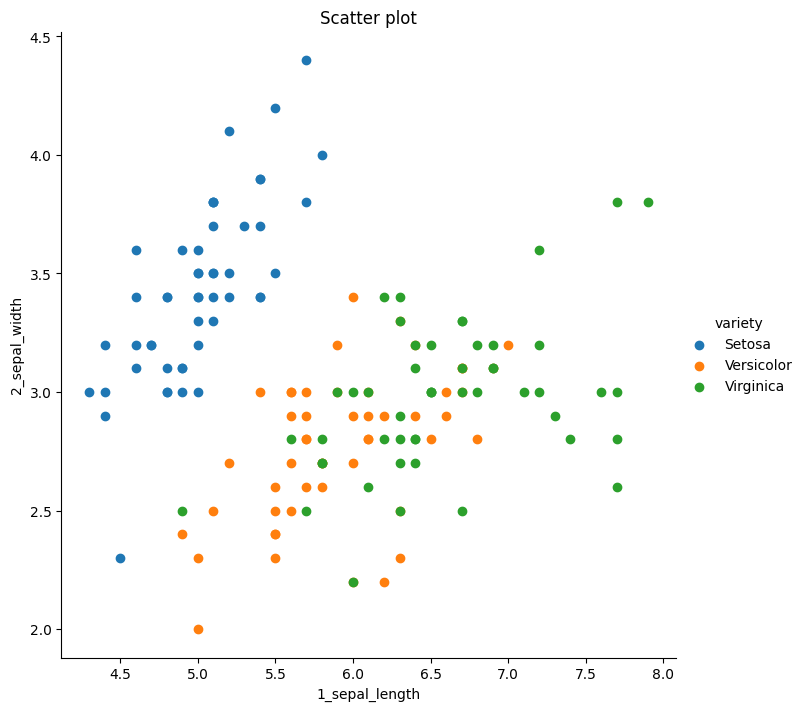

In [30]:
sns.FacetGrid(iris, hue = 'variety', height = 7).map(plt.scatter,
                                                   '1_sepal_length',
                                                   '2_sepal_width', ).add_legend()
plt.title('Scatter plot')

In [31]:
X_data = iris.iloc[:, :4].values.T
y_data = iris.iloc[:, 4].values

label_map = {label: idx for idx, label in enumerate(np.unique(y_data))}
y_num = np.array([label_map[label] for label in y_data])

# trộn dữ liệu 
N = X_data.shape[1]
perm = np.random.permutation(N)

X_data = X_data[:, perm]
y_num = y_num[perm]

split = int(0.8 * N)

X_train = X_data[:, :split]
X_val   = X_data[:, split:]

y_train = y_num[:split]
y_val   = y_num[split:]

In [32]:
# train 
C = len(np.unique(y_num))
d = X_train.shape[0]

W_init = np.random.randn(d, C)
eta = 0.05

W = softmax_regression(X_train, y_train, W_init, eta)
W_final = W[-1]


In [33]:
# prediction 
y_pred_train = pred(W_final, X_train)
y_pred_val   = pred(W_final, X_val)

In [34]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

print("Train accuracy:", accuracy(y_train, y_pred_train))
print("Validation accuracy:", accuracy(y_val, y_pred_val))

Train accuracy: 0.9583333333333334
Validation accuracy: 0.8666666666666667


- b) Chương trình Python với các hàm/phương thức từ thư viện Scikit-Learn
- Trong mục này, chúng ta sử dụng mô hình xây dựng từ lớp LogisticRegression trong gói
sklearn.linear_model (chú ý mô hình của chúng ta vẫn dựa trên tổ hợp tuyến tính và vẫn là hồi
quy logistic).

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sklearn
#from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
iris=load_iris()
# print(iris)
X=iris.data # Observed variable
Y=iris.target # Dependent variable (label)
#print(X.shape)
#print(Y.shape)
# Splitting Train and test Data
X_train,X_test,Y_train,Y_test=sklearn.model_selection.train_test_split(X,Y,test_size=0.2,
random_state=2)
#sc=StandardScaler()
#X_train=sc.fit_transform(X_train)
#X_test=sc.transform(X_test)
# Call to Logistic Regression Model - SAG: solving is based on Stochastic Average Gradient
lorg=LogisticRegression(multi_class='multinomial',solver='sag', max_iter=5000)
# and train model by Training Dataset
lorg.fit(X_train,Y_train)
# Then Predict the Test data
Y_pred=lorg.predict(X_test)
# for accuracy
from sklearn.metrics import accuracy_score
print(accuracy_score(Y_test,Y_pred))
# for confusion matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(Y_test,Y_pred)
print(cm)

0.9666666666666667
[[14  0  0]
 [ 0  7  1]
 [ 0  0  8]]


/home/datbritget/Documents/hocki-2-nam-3-toantin/hocky-2-nam-3-toantin-/machine_learning/exercise/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


- Từ ví dụ mẫu ở trên ta có thể thấy cách sử dụng mô hình hồi quy logistic của thư viện scikit-learn trong trường
hợp phân loại nhiều lớp tương tự như phân loại 2 lớp. Các bước thực hiện sẽ như sau:
- i. Load dữ liệu (tùy theo việc dữ liệu dạng gì và ở đâu)
- ii. Gán dữ liệu cho biến quan sát X và biến dự báo Y
- iii. Chia tập training và tập test nếu cần. Chú ý trường hợp dữ liệu do chúng ta tự tạo thì cần tự gán
tập dữ liệu test (không có nhãn).
- iv. Tạo đối tượng LogisticRegression của gói sklearn.linear_model (đã khai báo từ thư viên
scikit-learn)
- v. Tiến hành “huấn luyện” trên tập dữ liệu training để tìm hệ số tối ưu thông qua phương thức fit của
đối tượng nói trên:
<LogisticRegression object>.fit(X_train, Y_train)
- vi. Nếu có dữ liệu test, tiến hành dự đoán cho bộ dữ liệu test với mô hình và bộ tham số đã được tối
ưu theo dữ liệu huấn luyện
Y_predict = <LogisticRegression object>.predict(X_test)
- vii. Hiển thị kết quả/đánh giá độ chính xác/tính confusion matrix …

### Vi du B.3(Bai tap thuc hanh 2):
- Vận dụng kiến thức từ ví dụ trên, ta xây mô hình hồi quy Logistic phân
loại tập dữ liệu các đoạn văn bản ngắn lấy từ các bản tin được tổng hợp trong bộ dữ liệu có tên 20 NewsGroups.
Đây là bộ dữ liệu với trên 20000 bản tin ngắn (văn bản) được phân chia gần như đồng đều trong 20 lĩnh vực
thuộc 6 nhóm khác nhau như sau:
- Thông tin thêm về tập dữ liệu này có thể được tham khảo tại link: http://qwone.com/~jason/20Newsgroups /.
Trong ví dụ này, chúng ta không sử dụng văn bản gốc mà sẽ sử dụng dữ liệu đã được xử lý/số hóa (theo kỹ
thuật Bag-Of_Words) của nó, tức là dữ liệu có dạng vector như ví dụ trước.
Hơn nữa, cũng tương tự như bộ dữ liệu IRIS, bộ dữ liệu này đã được cung cấp sẵn trong gói scikit-learn,
chúng ta có thể gọi và sử dụng nó bằng các lệnh import thư viện (cho dữ liệu đã vector hóa):

In [5]:
from sklearn.datasets import fetch_20newsgroups_vectorized
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd 

In [16]:
n_samples = 2000
X, y = fetch_20newsgroups_vectorized(subset='all', return_X_y=True)
X = X[:n_samples]
y = y[:n_samples]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42,
stratify=y, test_size=0.1)
train_samples, n_features = X_train.shape
n_classes = np.unique(y).shape[0]

In [14]:
print(X_train.shape)
print(y_train.shape)

(1800, 130107)
(1800,)


- Hãy hoàn thiện mô hình hồi quy Logistic nhiều lớp để dự đoán cho mẫu dữ liệu này. Sau đó in ra độ chính
xác, ma trận Confusion Matrix của mô hình.

/home/datbritget/Documents/hocki-2-nam-3-toantin/hocky-2-nam-3-toantin-/machine_learning/exercise/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   35.8s finished



Accuracy: 81.45%


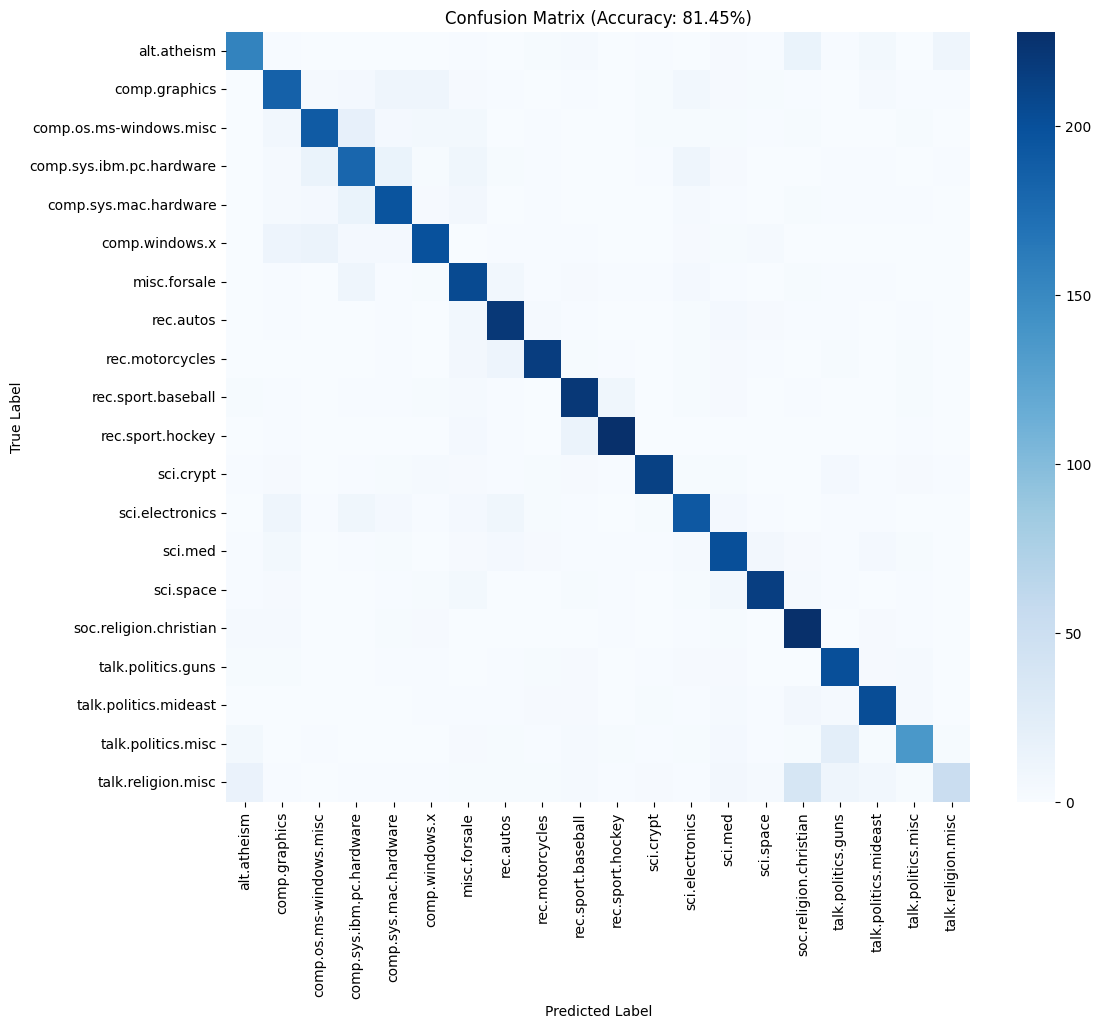

In [36]:
from sklearn.datasets import fetch_20newsgroups_vectorized
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load dữ liệu (đã được vector hóa sẵn)
n_samples = 20000
X, y = fetch_20newsgroups_vectorized(subset='all', return_X_y=True)
X = X[:n_samples]
y = y[:n_samples]

# 2. Chia tập Train/Test (Tỷ lệ 0.25 như đề bài gợi ý)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 3. Huấn luyện bằng LogisticRegression của sklearn
# multi_class='multinomial' chính là Softmax Regression
# solver='lbfgs' hoặc 'saga' chạy rất tốt với dữ liệu lớn
model = LogisticRegression(
    multi_class='multinomial', 
    solver='lbfgs', 
    max_iter=100,      # Tương đương với số epochs, mặc định 100 là đủ dùng
    verbose=1          # Để nó hiện quá trình chạy cho đỡ sốt ruột
)

model.fit(X_train, y_train)

# 4. Dự đoán
y_pred = model.predict(X_test)

# 5. Đánh giá
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy * 100:.2f}%")

# 6. Vẽ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Lấy tên các class để gắn vào trục cho chuyên nghiệp
newsgroups = fetch_20newsgroups_vectorized(subset='all')
class_names = newsgroups.target_names

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix (Accuracy: {accuracy*100:.2f}%)')
plt.xticks(rotation=90)
plt.show()

### Vi du B.4(Bai tap thuc hanh 3): 
- Ta xét ví dụ phân loại các loại kính trong tập dữ liệu nhận dạng kính
(Glass Identification Database) có thể download tại link:
https://raw.githubusercontent.com/jbrownlee/Datasets/master/glass.csv .

In [1]:
import os
import numpy as np
# set names to the paths because they're too long
data_path = '/home/datbritget/Documents/hocki-2-nam-3-toantin/hocky-2-nam-3-toantin-/machine_learning/exercise/ex4'
# train path
train_images_path = os.path.join(data_path, 'train-images-idx3-ubyte.gz')
train_labels_path = os.path.join(data_path, 'train-labels-idx1-ubyte.gz')
# test path
test_images_path = os.path.join(data_path, 't10k-images-idx3-ubyte.gz')
test_labels_path = os.path.join(data_path, 't10k-labels-idx1-ubyte.gz')

In [2]:
# Xây dựng phương thức đọc dữ liệu từ tệp gzip, giải nén và đưa về định dạng là một dãy ảnh (một dãy ma trận
#nguyên
def get_mnist_data(images_path, labels_path, num_images
, shuffle=False, _is=True, image_size=28):
    """
        This shuffle param is active when .gz is downloaded at:
        - 'http://yann.lecun.com/exdb/mnist/'
        - This function return random num_images in 60000 or 10000
    """
    # read data
    import gzip # to decompress gz (zip) file
    # open file training to read training data
    f_images = gzip.open(images_path,'r')
    # skip 16 first bytes because these are not data, only header infor
    f_images.read(16)
    # general: read num_images data samples if this parameter is set;
    # if not, read all (60000 training or 10000 test)
    real_num = num_images if not shuffle else (60000 if _is else 10000)
    # read all data to buf_images (28x28xreal_num)
    buf_images = f_images.read(image_size * image_size * real_num)
    # images
    images = np.frombuffer(buf_images, dtype=np.uint8).astype(np.float32)
    images = images.reshape(real_num, image_size, image_size,)
    # Read labels
    f_labels = gzip.open(labels_path,'r')
    f_labels.read(8)
    labels = np.zeros((real_num)).astype(np.int64)
    # rearrange to correspond the images and labels
    for i in range(0, real_num):
        buf_labels = f_labels.read(1)
        labels[i] = np.frombuffer(buf_labels, dtype=np.uint8).astype(np.int64)
        # shuffle to get random images data
    if shuffle is True:
        rand_id = np.random.randint(real_num, size=num_images)
        images = images[rand_id, :]
        labels = labels[rand_id,]
    # change images data to type of vector 28x28 dimentional
    images = images.reshape(num_images, image_size * image_size)
    return images, labels

In [3]:
# Gọi phương thức đọc dữ liệu để kiếm tra xem đọc đúng hay không: 
train_images, train_labels = get_mnist_data(
train_images_path, train_labels_path, 5000, shuffle=True)
test_images, test_labels = get_mnist_data(
test_images_path, test_labels_path, 10000, _is=False, shuffle=True)
print(train_images.shape, train_labels.shape)
print(test_images.shape, test_labels.shape)

(5000, 784) (5000,)
(10000, 784) (10000,)


/tmp/ipykernel_16690/2902978785.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels[i] = np.frombuffer(buf_labels, dtype=np.uint8).astype(np.int64)


In [4]:
# Convert matrix to image
def get_image(image):
    return image.reshape(28, 28)
# These methods are from Vi du 1
def convert_labels(y, C):
    from scipy import sparse
    Y = sparse.coo_matrix((np.ones_like(y),
        (y, np.arange(len(y)))), shape = (C, len(y))).toarray()
    return Y
def softmax(Z):
    e_Z = np.exp(Z)
    A = e_Z / e_Z.sum(axis = 0)
    return A
def softmax_stable(Z):
    e_Z = np.exp(Z - np.max(Z, axis = 0, keepdims = True))
    A = e_Z / e_Z.sum(axis = 0)
    return A
def pred(W, X):
    A = softmax_stable(W.T.dot(X))
    return np.argmax(A, axis = 0)

- Đoạn chương trình chứa thủ tục tính toán theo phương pháp lặp Gradient Descent ngẫu nhiên trong mô
hình hồi quy logistic cho dữ liệu nhiều lớp.

In [5]:
def _softmax_regression(X, Y, theta, lambda_=0.5, 
                        iterations=20, learning_rate=1e-5, batch_size=200):
    from sklearn.metrics import log_loss
    
    losses = []
    _theta = theta
    d, N = X.shape
    C = Y.shape[0] # Giả sử là 10 hoặc số lớp tương ứng
    
    for iter_ in range(iterations):
        shuffle_index = np.random.permutation(N)
        for i in shuffle_index:
            # 1. Stochastic Gradient Descent (Cập nhật theo từng điểm)
            xi = X[:, i].reshape(d, 1)
            yi = Y[:, i].reshape(C, 1)
            
            ai = softmax_stable(np.dot(_theta.T, xi))
            _theta += learning_rate * xi.dot((yi - ai).T)
            
            # 2. Tính Loss để theo dõi (Monitor)
            if (iter_ * N + i) % batch_size == 0:
                # Quan trọng: Tính xác suất toàn bộ X
                Z = np.dot(_theta.T, X)
                Y_hat = softmax_stable(Z) # Phải có Softmax ở đây!
                
                # Chuyển vị .T để khớp format (N, C) của sklearn
                curr_loss = log_loss(Y.T, Y_hat.T)
                losses.append(curr_loss)
        
        # In kết quả sau mỗi epoch
        Z_epoch = np.dot(_theta.T, X)
        Y_hat_epoch = softmax_stable(Z_epoch)
        # Không chia N ở đây vì log_loss đã tính average rồi
        print(f"epoch {iter_} - cost {log_loss(Y.T, Y_hat_epoch.T)}")
        
    return _theta, losses

0 4


<Figure size 640x480 with 0 Axes>

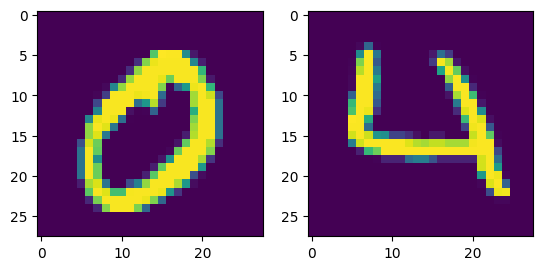

In [6]:
# for display and test digit :D
import random
import matplotlib.pyplot as plt
index = random.randint(0, 1000)
print(train_labels[index], test_labels[index])
train_image = np.asarray(get_image(train_images[index])).squeeze()
test_image = np.asarray(get_image(test_images[index])).squeeze()
plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, 2)
# use the created array to output your multiple images. In this case I have
# stacked 4 images vertically
axarr[0].imshow(train_image)
axarr[1].imshow(test_image)
plt.show()

(785, 5000)
(10, 5000)


<Figure size 640x480 with 0 Axes>

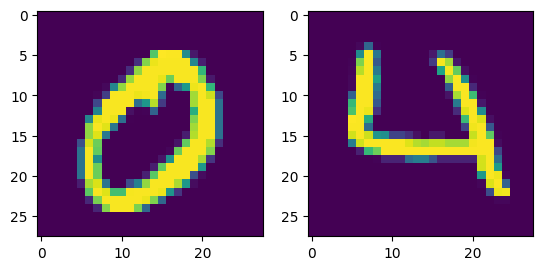

In [7]:
# prediction 
X_train = np.concatenate((np.ones((1, train_images.shape[0])), train_images.T),
axis = 0)
Y_train = convert_labels(train_labels, 10)
print(X_train.shape)
print(Y_train.shape)
train_image = np.asarray(get_image(train_images[index])).squeeze()
test_image = np.asarray(get_image(test_images[index])).squeeze()
plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, 2)
# use the created array to output your multiple images. In this case I have
#stacked 4 images vertically
axarr[0].imshow(train_image)
axarr[1].imshow(test_image)
plt.show()

In [8]:
theta = np.zeros((X_train.shape[0], 10))
opt_theta, losses = _softmax_regression(X_train, Y_train, theta)
print('training success: ', opt_theta.shape, len(losses))

epoch 0 - cost 3.8862239474149463
epoch 1 - cost 2.4770573249523102
epoch 2 - cost 4.174725308290316
epoch 3 - cost 2.8402553279484826
epoch 4 - cost 2.6157008121948593
epoch 5 - cost 1.7325491648181057
epoch 6 - cost 1.4125509222535317
epoch 7 - cost 1.6798723895363141
epoch 8 - cost 1.5841411549036497
epoch 9 - cost 3.60589738054958
epoch 10 - cost 1.5743886302869716
epoch 11 - cost 1.7468888109523992
epoch 12 - cost 0.925782616224038
epoch 13 - cost 1.2793350274647397
epoch 14 - cost 1.208071249459689
epoch 15 - cost 1.462315820020647
epoch 16 - cost 1.4075576111860502
epoch 17 - cost 1.226727332702296
epoch 18 - cost 0.8382566385087546
epoch 19 - cost 0.9334402744798359
training success:  (785, 10) 500


- Tính các thông số về độ chính xác (gọi thư viện để chương trình không quá dài)

In [9]:
from sklearn.metrics import accuracy_score
print('accuracy training data: ', accuracy_score(train_labels,
pred(opt_theta, X_train)))
# test_images, test_labels = get_mnist_data(
# test_images_path, test_labels_path, 1000, _is=False, shuffle=False)
X_test = np.concatenate((np.ones((1, test_images.shape[0])), test_images.T),
axis = 0)
print(X_test.shape)
print('accuracy testing data: ', accuracy_score(test_labels,
pred(opt_theta, X_test)))

accuracy training data:  0.9466
(785, 10000)
accuracy testing data:  0.8708


### (Bai thuc hanh 4)
- 1) Sử dụng đoạn code chọn số chiều chính trong ví dụ 2, đưa tập dữ liệu đã đọc về còn 2 chiều, sau
đó hiển thị lên màn hình để xem quan hệ giữa các lớp dữ liệu.
- 2) Với đoạn chương trình đọc dữ liệu đã có, hãy chạy lại ví dụ này với các thư viện của gói
linear_model, lớp LogisticRegression và so sánh kết quả

In [12]:
import pandas as pd
from sklearn.decomposition import PCA as sklearnPCA
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

/tmp/ipykernel_16690/2902978785.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels[i] = np.frombuffer(buf_labels, dtype=np.uint8).astype(np.int64)


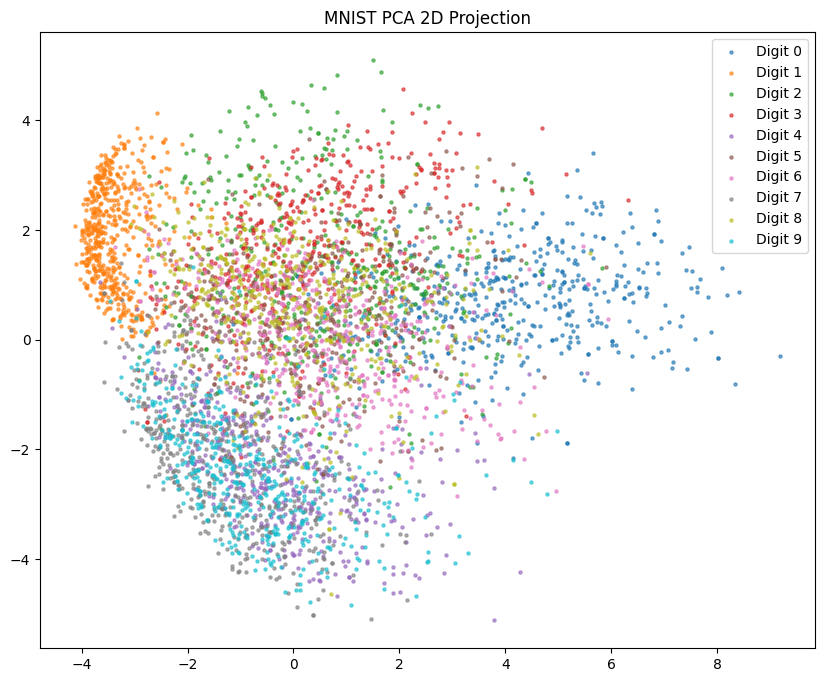

In [15]:
# 1. Lấy dữ liệu (Sử dụng hàm get_mnist_data bạn đã viết)
train_images, train_labels = get_mnist_data(train_images_path, train_labels_path, 5000, shuffle=True)

# 2. Chuẩn hóa dữ liệu về [0, 1] - Rất quan trọng cho PCA
X_norm = train_images / 255.0 

# 3. Áp dụng PCA giảm xuống 2 chiều [cite: 124, 583]
pca = sklearnPCA(n_components=2)
transformed = pd.DataFrame(pca.fit_transform(X_norm))

# 4. Hiển thị (Vẽ 10 class từ 0-9) [cite: 126, 132]
plt.figure(figsize=(10, 8))
for i in range(10):
    mask = (train_labels == i)
    plt.scatter(transformed[mask][0], transformed[mask][1], s=5, label=f'Digit {i}', alpha=0.6)

plt.legend()
plt.title("MNIST PCA 2D Projection")
plt.show()

/home/datbritget/Documents/hocki-2-nam-3-toantin/hocky-2-nam-3-toantin-/machine_learning/exercise/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Epoch 1, change: 1
Epoch 2, change: 0.30658853
Epoch 3, change: 0.23675393
Epoch 4, change: 0.15387532
Epoch 5, change: 0.11106894
Epoch 6, change: 0.097996637
Epoch 7, change: 0.078348048
Epoch 8, change: 0.062659055
Epoch 9, change: 0.053597003
Epoch 10, change: 0.037795208
Epoch 11, change: 0.036244217
Epoch 12, change: 0.03564306
Epoch 13, change: 0.029568028
Epoch 14, change: 0.026099421
Epoch 15, change: 0.022137927
Epoch 16, change: 0.021281062
Epoch 17, change: 0.021206446
Epoch 18, change: 0.019437371
Epoch 19, change: 0.017455177
Epoch 20, change: 0.016853867
Epoch 21, change: 0.014474704
Epoch 22, change: 0.014740234
Epoch 23, change: 0.013506504
Epoch 24, change: 0.012668456
Epoch 25, change: 0.012667204
Epoch 26, change: 0.011641482
Epoch 27, change: 0.011004944
Epoch 28, change: 0.010471026
Epoch 29, change: 0.0099371085
Epoch 30, change: 0.0094833784
Epoch 31, change: 0.0093886722
Epoch 32, change: 0.0091787521
Epoch 33, change: 0.008787768
Epoch 34, change: 0.0084939795

/home/datbritget/Documents/hocki-2-nam-3-toantin/hocky-2-nam-3-toantin-/machine_learning/exercise/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    7.8s finished


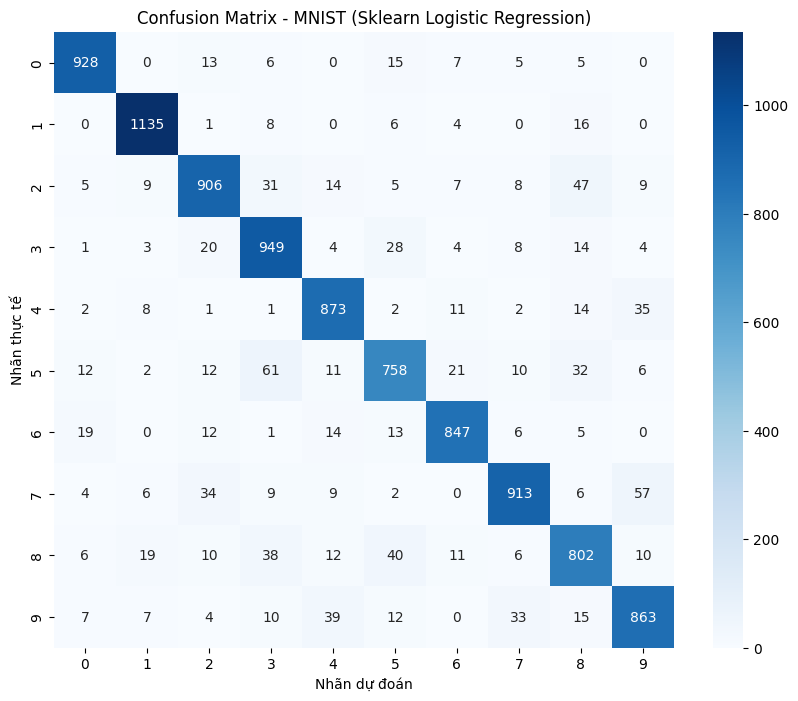

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Chuẩn hóa dữ liệu về khoảng [0, 1] để hội tụ nhanh hơn
X_train_final = train_images / 255.0
X_test_final = test_images / 255.0

# 2. Khởi tạo mô hình Logistic Regression từ sklearn
# multi_class='multinomial' tương ứng với Softmax Regression 
# solver='sag' (Stochastic Average Gradient) tối ưu cho tập dữ liệu lớn 
lorg = LogisticRegression(
    multi_class='multinomial', 
    solver='sag', 
    max_iter=100, # Theo tài liệu, MNIST nên chạy khoảng 5-8 epochs nếu code tay, 
                  # với sklearn 100 iterations là đủ tốt [cite: 354]
    verbose=1
)

# 3. Huấn luyện mô hình (Fitting) [cite: 295, 317]
lorg.fit(X_train_final, train_labels)

# 4. Dự đoán trên tập dữ liệu Test [cite: 297, 321]
y_pred_sklearn = lorg.predict(X_test_final)

# 5. Tính toán và in độ chính xác (Accuracy) [cite: 300, 322]
acc_train = accuracy_score(train_labels, lorg.predict(X_train_final))
acc_test = accuracy_score(test_labels, y_pred_sklearn)

print(f"Độ chính xác trên tập Train (Sklearn): {acc_train * 100:.2f}%")
print(f"Độ chính xác trên tập Test (Sklearn): {acc_test * 100:.2f}%")

# 6. Hiển thị Ma trận nhầm lẫn (Confusion Matrix) [cite: 303, 322]
cm = confusion_matrix(test_labels, y_pred_sklearn)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Nhãn dự đoán')
plt.ylabel('Nhãn thực tế')
plt.title('Confusion Matrix - MNIST (Sklearn Logistic Regression)')
plt.show()